## 1. Objects and Classes

- Create a seeded random number generator with `np.random.default_rng()`
- Define a class `Experiment` that stores a `name` and a NumPy array of `values`, with a method `summary()` that returns the mean and standard deviation of `values`
- Create two `Experiment` objects with simulated data from `rng.normal()`, each with a different `loc` and `scale`, and call `summary()` on each
- In a Markdown cell, answer: which parts of `Experiment` are attributes and which are methods? How close is each `summary()` to the `loc` and `scale` you used?

In [45]:
import matplotlib.pyplot as plt
import numpy as np

In [46]:
rng = np.random.default_rng(seed = 42)

class Experiment:
    def __init__(self, name, values):
        self.name = name
        self.values = np.array(values)
    def summary(self):
        mean = np.mean(self.values)
        std = np.std(self.values)
        return mean, std
        
# from module 3: 
#  - `rng.normal(loc, scale, size)`: draw from a Normal distribution
#  - `loc`: the mean
#  - `scale`: the standard deviation
#  - `size`: the shape of the output (an int, or a tuple for multiple dimensions)

simulated_data1 = rng.normal(122, 12, size=(1,100))
simulated_data2 = rng.normal(342, 23, size=(1,100))

data_test_1 = Experiment('Data 1', simulated_data1)
data_test_2 = Experiment('Data 2', simulated_data2)

data_test_1.summary(), data_test_2.summary()


((np.float64(121.39676466219369), np.float64(9.273408900069404)),
 (np.float64(341.7554677301183), np.float64(22.41588726668262)))

From Class Notes:
Classes, also called Objects, are containers in Python that can store values, known as `attributes`; and functions, known as `methods`
Attributes are accessed with a `.` and no parentheses. Methods are called with `()`, just like functions.

Based on this, we know that name and values are attributes, while the only method is summary. 
Summary is relatively close to the mean and std defined in the random normal distributions I made, the 122 mean and 12 std became 121 and 9.27, which are pretty reasonable, though the std. is slightly lower than expected. Similarly the other random normal distribution had a mean of 342 and std of 23, and this was well maintained with summary giving a mean of 341.8 and std of 22.4, which are very reasonable values.  

## 2. Loading Data

- Load `notebooks/data/RNAcountTable_chr1_geneNames.tsv` into a DataFrame called `df` with `pd.read_csv()`. The columns are separated by tabs, and your path depends on where your notebook is saved relative to the `data` folder.
- Show the first 5 and the last 5 rows
- Print the `shape`, `columns`, and `dtypes` of `df`
- In a Markdown cell, answer: how many genes and how many samples are in the data? What does each row represent, and what does each number in the table represent?

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv('data/RNAcountTable_chr1_geneNames.tsv', sep='\t')

In [49]:
df.head(5), df.tail(5)

(      Gene  FB_1  FB_2  HSC_1  HSC_2  TREG_1  TREG_2
 0     Xkr4     2     0      0      0       0       0
 1  Gm19938     0     6      0      0       0       0
 2  Gm10568     0     0      0      0       0       0
 3      Rp1     0     0      0      2       2       0
 4    Sox17     0     0      0      0       0       0,
           Gene   FB_1   FB_2  HSC_1  HSC_2  TREG_1  TREG_2
 1396  Mir29b-2      0      0      0      0       0       0
 1397    Mir29c      0      0      0      0       0       0
 1398      Cd46     27    109    118    136      34     150
 1399      Cr1l   6590  11545  14338  14217   11196   16761
 1400       Cr2  39427  87703    140    252      10      18)

In [50]:
df.shape, df.columns, df.dtypes

((1401, 7),
 Index(['Gene', 'FB_1', 'FB_2', 'HSC_1', 'HSC_2', 'TREG_1', 'TREG_2'], dtype='str'),
 Gene        str
 FB_1      int64
 FB_2      int64
 HSC_1     int64
 HSC_2     int64
 TREG_1    int64
 TREG_2    int64
 dtype: object)

How many genes: 1401

How many samples are in the data: 6

What does each row represent: One gene

What does each number in the table represent: gene count of that gene in the dataset

## 3. Renaming and Selecting Data

- Rename the `Gene` column to `gene`
- Use `.iloc` to select the first 5 genes and the first 3 sample columns
- Use `.loc` to select the `gene`, `FB_1`, and `FB_2` columns for the genes `Fcmr`, `Sell`, and `Ptprc`. Hint: `df['gene'].isin(['Fcmr', 'Sell', 'Ptprc'])` gives a Boolean Series.
- Use `.query()` to select the genes with a count above 100,000 in `FB_1`
- Count how many genes have a count of 0 in all six samples. Hint: `df[sample_columns].sum(axis=1)` adds up each row, where `sample_columns` is a list of your six sample column names.
- In a Markdown cell, answer: how do `Fcmr`, `Sell`, and `Ptprc` compare across the two replicates of `FB`? What fraction of the genes were not detected in any sample?


In [51]:
df = df.rename(
    columns = {
        'Gene': 'gene',
})
df.columns


Index(['gene', 'FB_1', 'FB_2', 'HSC_1', 'HSC_2', 'TREG_1', 'TREG_2'], dtype='str')

In [52]:
top_5gene_3sample = df.iloc[:5, :4]
top_5gene_3sample

,gene,FB_1,FB_2,HSC_1
0,Xkr4,2,0,0
1,Gm19938,0,6,0
2,Gm10568,0,0,0
3,Rp1,0,0,0
4,Sox17,0,0,0


In [53]:
selected_genes = df.loc[df['gene'].isin(['Fcmr', 'Sell', 'Ptprc']), ['gene', 'FB_1', 'FB_2']]
selected_genes

,gene,FB_1,FB_2
775,Fcmr,181367,234108
890,Ptprc,76859,145446
1055,Sell,84538,133520


In [54]:
data_FB_1 = df.loc[:, ['FB_1']]
data_FB_1

df_over100k = data_FB_1.query("FB_1 > 100000")
df_over100k

,FB_1
775,181367


In [55]:
sample_columns = ['FB_1', 'FB_2', 'HSC_1', 'HSC_2', 'TREG_1', 'TREG_2']
summing_column = df[sample_columns].sum(axis=1)

genes_of_zero = 0
for data in summing_column:
    if data == 0:
        genes_of_zero += 1
genes_of_zero

211

In [64]:
selected_genes

,gene,FB_1,FB_2
775,Fcmr,181367,234108
890,Ptprc,76859,145446
1055,Sell,84538,133520


When looking at Fcmr, Sell, and Ptprc we see that across the two replicates of FB they are actually not very well aligned. Though they are in similar values the FB_1 gene counts much lower than the FB_2 gene counts, for Ptprc the counts are almost halved in FB_1 compared to FB_2 while the other two genes are also lower in the FB_1 just not as big of a difference. 

What fraction of the genes were not detected in any sample?

There are a total of 1401 genes and 211 of them were not detected in any sample, so 211/1401 = 0.1506067095

## 4. Summary Statistics

- Compute the total counts for each sample: `df[sample_columns].sum()`
- Compute the mean and median count of each sample
- Run `.describe()` on `df`
- In a Markdown cell, answer: are the six samples similar in their total counts? For each sample, is the mean or the median larger, and what does that tell you about how the counts are distributed across genes?


In [65]:
# total counts for each sample:
df[sample_columns].sum()

FB_1      2975457
FB_2      4896508
HSC_1     5217507
HSC_2     5250836
TREG_1    4410961
TREG_2    6673503
dtype: int64

In [67]:
df[sample_columns].mean(), df[sample_columns].median()

(FB_1      2123.809422
 FB_2      3495.009279
 HSC_1     3724.130621
 HSC_2     3747.920057
 TREG_1    3148.437545
 TREG_2    4763.385439
 dtype: float64,
 FB_1       2.0
 FB_2      32.0
 HSC_1     97.0
 HSC_2     75.0
 TREG_1    26.0
 TREG_2    58.0
 dtype: float64)

In [68]:
df.describe()

,FB_1,FB_2,HSC_1,HSC_2,TREG_1,TREG_2
count,1401.000000,1401.000000,1401.000000,1401.000000,1401.000000,1401.000000
mean,2123.809422,3495.009279,3724.130621,3747.920057,3148.437545,4763.385439
std,7875.145747,12200.334314,9276.334397,9290.327241,9867.037958,15005.384674
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,32.000000,97.000000,75.000000,26.000000,58.000000
75%,1381.000000,2430.000000,3824.000000,3795.000000,2113.000000,3496.000000
max,181367.000000,234108.000000,122880.000000,122145.000000,146046.000000,235645.000000


Are the six samples similar in their total counts? For each sample, is the mean or the median larger, and what does that tell you about how the counts are distributed across genes?

The six sample count totals are:
FB_1      2975457
FB_2      4896508
HSC_1     5217507
HSC_2     5250836
TREG_1    4410961
TREG_2    6673503

The counts are all of the same order of magnitude and are relatively similar, though the FB's trend towards lower counts than the HSC and TREG counts. The means are larger in all of the samples, so the data is skewed towards the right, which makes sense because some of the genes will have very high counts which skews the mean up, while the median is less impacted by that. This tells us that the counts are not evenly distributed across genes with some genes having very high counts and others very low.  

## 5. Extracting Metadata

Right now, the cell type and the replicate are stuck in the column names. Let's put them in their own columns.

- Use `.melt()` to turn `df` into a long DataFrame called `df_long` with the columns `gene`, `sample`, and `count`
- Use `.str.split()` on `sample` to add `group` (the cell type) and `replicate` columns
- Print the `shape` of `df_long`
- In a Markdown cell, answer: why does `df_long` have the number of rows that it has? What does each row represent now?


In [91]:
df_long = df.melt(id_vars='gene', var_name='sample', value_name='count')
df_long

,gene,sample,count
0,Xkr4,FB_1,2
1,Gm19938,FB_1,0
2,Gm10568,FB_1,0
3,Rp1,FB_1,0
4,Sox17,FB_1,0
...,...,...,...
8401,Mir29b-2,TREG_2,0
8402,Mir29c,TREG_2,0
8403,Cd46,TREG_2,150
8404,Cr1l,TREG_2,16761


In [92]:
df_long[['group', 'replicate']] = df_long['sample'].str.split('_', expand=True)
df_long

,gene,sample,count,group,replicate
0,Xkr4,FB_1,2,FB,1
1,Gm19938,FB_1,0,FB,1
2,Gm10568,FB_1,0,FB,1
3,Rp1,FB_1,0,FB,1
4,Sox17,FB_1,0,FB,1
...,...,...,...,...,...
8401,Mir29b-2,TREG_2,0,TREG,2
8402,Mir29c,TREG_2,0,TREG,2
8403,Cd46,TREG_2,150,TREG,2
8404,Cr1l,TREG_2,16761,TREG,2


In [93]:
df_long.shape

(8406, 5)

Why does `df_long` have the number of rows that it has? What does each row represent now?

Each one of the individual samples had 1401 genes, now all the 6 samples are in a row so 1401*6 = 8406 rows (since it starts with zero). It has all 8406 rows because the samples are now one ofter the other. However, each row represents a specific gene and sample combination, with each gene being repreated 6 times in the gene column, such that there is one per sample. 


## 6. Group-Apply-Combine

- Use `groupby` to compute the mean and median `count` for each `group`
- Use `groupby` on `group` and `gene` to compute the mean `count` of each gene in each cell type, and use `.reset_index()`
- Sort that result to find the top 5 genes in each cell type. Hint: `.sort_values('count', ascending=False)` and `.groupby('group').head(5)`.
- In a Markdown cell, answer: which gene has the highest mean count in each cell type? Are any genes in the top 5 of more than one cell type?


In [94]:
df_long.groupby('group')['count'].mean()

group
FB      2809.409350
HSC     3736.025339
TREG    3955.911492
Name: count, dtype: float64

In [95]:
df_long.groupby('group')['count'].median()

group
FB      13.0
HSC     85.0
TREG    37.0
Name: count, dtype: float64

In [96]:
mean_count = df_long.groupby(['group', 'gene'])['count'].mean().reset_index()
mean_count

,group,gene,count
0,FB,1-Mar,2.5
1,FB,1500015O10Rik,0.0
2,FB,1600012P17Rik,0.0
3,FB,1700001G17Rik,21.0
4,FB,1700007P06Rik,0.0
...,...,...,...
4198,TREG,Zfp142,1608.5
4199,TREG,Zfp281,13402.0
4200,TREG,Zfp451,3571.5
4201,TREG,Zp3r,15.0


In [97]:
mean_count.sort_values('count', ascending=False).groupby('group').head(5)

,group,gene,count
469,FB,Fcmr,207737.5
3853,TREG,Ptprc,190845.5
4032,TREG,Stat1,152516.5
3939,TREG,Sell,141098.0
2917,TREG,Actr3,139598.5
2049,HSC,Hnrnpu,122512.5
2970,TREG,Arpc2,120677.0
115,FB,Actr3,111199.0
1051,FB,Ptprc,111152.5
1137,FB,Sell,109029.0


Which gene has the highest mean count in each cell type? Are any genes in the top 5 of more than one cell type?

Fcmr has the highest mean count in the FB type, Ptprc has the highest mean count in the TREG cell type and Hnrnpu had the highest mean count in the HSC cell type. 
Ptprc is in the tip 5 for both TREG and FB cells, Sell is in the top 5 for TREG and FB cells, Actr3 is in the top 5 for TREGs and FB cells, Arpc2 is in the top 5 for TREG, FB and HSCs. 

## 7. Plotting with Seaborn

Read counts span several orders of magnitude, so we'll plot them on a log scale.

- Add a column `log_count` to `df_long` with `np.log2(df_long['count'] + 1)`. The `+ 1` is there because `log2(0)` is undefined.
- Using `fig, axes = plt.subplots()` with two subplots side by side:
  - On the left, a `sns.histplot()` of `log_count` with `hue='group'`
  - On the right, a `sns.boxplot()` of `log_count` by `group`, with `hue='replicate'`
- Make a second figure: a scatterplot of the two `FB` replicates against each other, using `np.log2(df['FB_1'] + 1)` and `np.log2(df['FB_2'] + 1)`
- Add a title and axis labels to every plot, and save your figures with `fig.savefig()`
- In a Markdown cell, answer: what shape do the distributions of `log_count` have, and why? How well do the two `FB` replicates agree, and why would we want them to?


In [98]:
df_long['log_count'] = np.log2(df_long['count'] + 1)
df_long

,gene,sample,count,group,replicate,log_count
0,Xkr4,FB_1,2,FB,1,1.584963
1,Gm19938,FB_1,0,FB,1,0.000000
2,Gm10568,FB_1,0,FB,1,0.000000
3,Rp1,FB_1,0,FB,1,0.000000
4,Sox17,FB_1,0,FB,1,0.000000
...,...,...,...,...,...,...
8401,Mir29b-2,TREG_2,0,TREG,2,0.000000
8402,Mir29c,TREG_2,0,TREG,2,0.000000
8403,Cd46,TREG_2,150,TREG,2,7.238405
8404,Cr1l,TREG_2,16761,TREG,2,14.032907


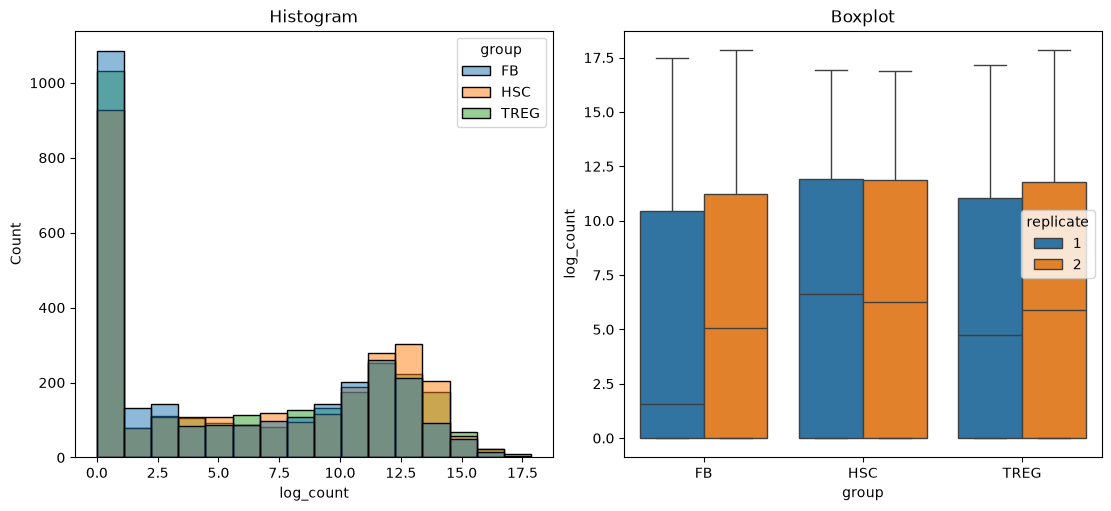

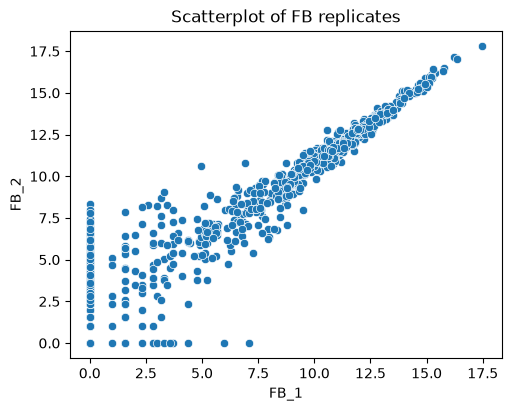

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), layout='constrained')
sns.histplot(data=df_long, x='log_count', hue='group', ax=axes[0])
sns.boxplot(data=df_long, x='group', y='log_count', hue='replicate', ax=axes[1])
axes[0].set_title('Histogram')
axes[1].set_title('Boxplot')
fig.savefig('histogram_and_boxplot.png')

fig, ax = plt.subplots(figsize=(5, 4), layout='constrained')
sns.scatterplot(data=df_long, x= np.log2(df['FB_1'] + 1), y=np.log2(df['FB_2'] + 1), ax=ax)
ax.set_title('Scatterplot of FB replicates')
fig.savefig('scatterplot.png')


What shape do the distributions of `log_count` have, and why? How well do the two `FB` replicates agree, and why would we want them to?

Log count shows a right skew but there is also a high number of zero gene counts. This shape makes sense because lots of genes are not expressed in different cell types and then whenthey are expressed there can be very differen cell counts. The FB replicates don't agree very well, this can be seen in the boxplot and the scatterplot of the FB replicates, in the boxplot you see the means for the replicates are very different, and in the scatterplot the higher log count values do agree well but the lower ones do not. We want them to agree because they are replicates, if the replicates don't agree this could point to different errors in the samples preparation or analysis. 